# ARE Benchmark — Modelos Locais via Ollama

Replica o benchmark [ARE (An R Eval)](https://github.com/diegoamrg4123/are-dataset-csv) usando modelos locais OSS via Ollama.  
O juiz é também um modelo local — sem dependência de APIs externas.

**Dependências:** `pip install ollama pandas matplotlib seaborn`  
**Pré-requisito:** Ollama rodando (`ollama serve`) com os modelos instalados.

In [1]:
import re
import pandas as pd
import numpy as np
import ollama
import json
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path
from datetime import datetime
from IPython.display import display

sns.set_theme(style="whitegrid", palette="muted")

## Configuração
Edite `MODELS` e `JUDGE_MODEL` conforme os modelos instalados (`ollama list`).

In [2]:
OLLAMA_HOST = "http://192.168.1.37:11434"

MODELS = [
    "lfm2.5-thinking:1.2b",
    "qwen3.5:2b",
    "qwen2.5-coder:3b",
    "gemma4:e2b",
]

JUDGE_MODEL = "gpt-oss:20b"

EPOCHS = 3

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

client = ollama.Client(host=OLLAMA_HOST)
print(f"Conectado ao Ollama em {OLLAMA_HOST}")

Conectado ao Ollama em http://192.168.1.37:11434


## Dataset

In [3]:
url = "https://raw.githubusercontent.com/diegoamrg4123/are-dataset-csv/main/are_dataset.csv"
df = pd.read_csv(url, sep=";", encoding="utf-8")
print(f"{len(df)} problemas carregados")
display(df.head(2))

29 problemas carregados


,id,input,target,domain,task,source,knowledge
0,after-stat-bar-heights,This bar chart shows the count of different cu...,Preferably: \n\n```\nggplot(data = diamonds) +...,Data analysis,New code,https://jrnold.github.io/r4ds-exercise-solutio...,tidyverse
1,conditional-grouped-summary,I have a set of data not unlike the following ...,One solution is to `group_by()` and summarize:...,Data analysis,New code,https://forum.posit.co/t/dplyr-case-when-summa...,tidyverse


## Solver
Envia o enunciado para o modelo avaliado e retorna a resposta.

In [4]:
SOLVER_SYSTEM = "You are an expert R programmer. Answer concisely with working R code."

def solve(model: str, problem: str) -> str:
    response = client.chat(
        model=model,
        messages=[
            {"role": "system", "content": SOLVER_SYSTEM},
            {"role": "user",   "content": problem}
        ]
    )
    return response["message"]["content"]

## Juiz / Scorer (partial credit)
Replica `model_graded_qa(partial_credit=TRUE)` do script R original.  
O juiz classifica cada resposta como **C** (correto), **P** (parcial) ou **I** (incorreto).

In [5]:
JUDGE_PROMPT = """\
You are an expert R programmer evaluating an answer to an R coding task.

## Question
{question}

## Expected answer / grading rubric
{target}

## Model response
{response}

Grade the response with a single letter:
- C  (correct)  — fully achieves the task
- P  (partial)  — on the right track but incomplete or has minor errors
- I  (incorrect) — wrong or completely off

Reply with ONLY the letter C, P, or I."""

SCORE_MAP = {"C": 1.0, "P": 0.5, "I": 0.0}

def judge(question: str, target: str, response: str) -> float:
    result = client.chat(
        model=JUDGE_MODEL,
        messages=[{"role": "user", "content": JUDGE_PROMPT.format(
            question=question, target=target, response=response
        )}]
    )
    letter = result["message"]["content"].strip().upper()[0]
    return SCORE_MAP.get(letter, 0.0)

## Pipeline: Solver → Juiz

Execução em duas fases para minimizar trocas de modelo no Ollama:

1. **Fase 1 — Solver**: cada modelo responde todos os problemas de uma vez antes de ser descarregado. Respostas intermediárias salvas em `results/<model>_responses.json`.
2. **Fase 2 — Juiz**: o juiz é carregado uma única vez e avalia todas as respostas acumuladas. Resultados finais salvos em `results/<model>.json`.

In [6]:
def run_solver(model: str, overwrite: bool = False):
    safe_name = model.replace(":", "_").replace("/", "_")
    responses_path = RESULTS_DIR / f"{safe_name}_responses.json"

    if not overwrite and responses_path.exists():
        print(f"Skipping solver {model} — respostas ja existem em {responses_path}")
        return

    records = []
    total = len(df) * EPOCHS
    done = 0

    for epoch in range(1, EPOCHS + 1):
        for _, row in df.iterrows():
            done += 1
            print(f"[{model}] epoch {epoch}/{EPOCHS} | {row['id']} ({done}/{total})")
            records.append({
                "model":    model,
                "epoch":    epoch,
                "id":       row["id"],
                "domain":   row["domain"],
                "task":     row["task"],
                "input":    row["input"],
                "target":   row["target"],
                "response": solve(model, row["input"]),
                "ts":       datetime.now().isoformat(),
            })

    responses_path.write_text(json.dumps(records, ensure_ascii=False, indent=2), encoding="utf-8")
    print(f"[{model}] {len(records)} respostas salvas em {responses_path}\n")


def run_judge_all(overwrite: bool = False):
    pending = []  # lista de (record, result_path)

    for responses_path in sorted(RESULTS_DIR.glob("*_responses.json")):
        safe_name = responses_path.stem.removesuffix("_responses")
        result_path = RESULTS_DIR / f"{safe_name}.json"

        if not overwrite and result_path.exists():
            print(f"Skipping juiz para {safe_name} — resultado ja existe")
            continue

        for record in json.loads(responses_path.read_text(encoding="utf-8")):
            pending.append((record, result_path))

    if not pending:
        print("Nada para julgar — todos os resultados ja existem.")
        return

    print(f"Juiz [{JUDGE_MODEL}] avaliando {len(pending)} respostas...\n")

    results_by_path: dict[str, tuple] = {}
    for i, (record, result_path) in enumerate(pending, 1):
        print(f"[juiz] {i}/{len(pending)} | {record['model']} ep{record['epoch']} | {record['id']}", end=" ... ")
        score = judge(record["input"], record["target"], record["response"])
        print(f"score={score}")

        key = str(result_path)
        if key not in results_by_path:
            results_by_path[key] = (result_path, [])
        results_by_path[key][1].append({
            "model":    record["model"],
            "epoch":    record["epoch"],
            "id":       record["id"],
            "domain":   record["domain"],
            "task":     record["task"],
            "score":    score,
            "response": record["response"],
            "ts":       record["ts"],
        })

    for result_path, records in results_by_path.values():
        result_path.write_text(json.dumps(records, ensure_ascii=False, indent=2), encoding="utf-8")
        mean_score = sum(r["score"] for r in records) / len(records)
        print(f"\n[{result_path.stem}] mean score: {mean_score:.3f} | salvo em {result_path}")

## Execução

**Fase 1**: todos os modelos respondem os benchmarks sequencialmente, um por vez.  
**Fase 2**: o juiz carrega uma única vez e avalia todas as respostas acumuladas.

In [7]:
# Fase 1 — cada modelo responde todos os problemas antes do próximo ser carregado
for model in MODELS:
    run_solver(model)

# Fase 2 — juiz carrega uma vez e avalia todas as respostas acumuladas
run_judge_all()

[lfm2.5-thinking:1.2b] epoch 1/3 | after-stat-bar-heights (1/87)
[lfm2.5-thinking:1.2b] epoch 1/3 | conditional-grouped-summary (2/87)
[lfm2.5-thinking:1.2b] epoch 1/3 | correlated-delays-reasoning (3/87)
[lfm2.5-thinking:1.2b] epoch 1/3 | curl-http-get (4/87)
[lfm2.5-thinking:1.2b] epoch 1/3 | dropped-level-legend (5/87)
[lfm2.5-thinking:1.2b] epoch 1/3 | filter-multiple-conditions (6/87)
[lfm2.5-thinking:1.2b] epoch 1/3 | geocode-req-perform (7/87)
[lfm2.5-thinking:1.2b] epoch 1/3 | group-by-summarize-message (8/87)
[lfm2.5-thinking:1.2b] epoch 1/3 | grouped-filter-summarize (9/87)
[lfm2.5-thinking:1.2b] epoch 1/3 | grouped-geom-line (10/87)
[lfm2.5-thinking:1.2b] epoch 1/3 | grouped-mutate (11/87)
[lfm2.5-thinking:1.2b] epoch 1/3 | grouped-proportions (12/87)
[lfm2.5-thinking:1.2b] epoch 1/3 | implement-nse-arg (13/87)
[lfm2.5-thinking:1.2b] epoch 1/3 | jitter-one-axis (14/87)
[lfm2.5-thinking:1.2b] epoch 1/3 | lazy-eval (15/87)
[lfm2.5-thinking:1.2b] epoch 1/3 | nested-servers (16/

## Análise de Resultados

In [8]:
all_records = []
for p in RESULTS_DIR.glob("*.json"):
    if not p.name.endswith("_responses.json"):
        all_records.extend(json.loads(p.read_text(encoding="utf-8")))

if not all_records:
    print("Nenhum resultado encontrado em results/. Execute o benchmark primeiro.")
else:
    results_df = pd.DataFrame(all_records)

    print("=== Score médio por modelo ===")
    summary = (
        results_df
        .groupby("model")["score"]
        .agg(mean="mean", std="std", n="count")
        .sort_values("mean", ascending=False)
        .round(3)
    )
    display(summary)

=== Score médio por modelo ===


,mean,std,n
model,,,
gemma4:e2b,0.287,0.401,87
qwen3.5:2b,0.236,0.395,87
qwen2.5-coder:3b,0.190,0.368,87
lfm2.5-thinking:1.2b,0.052,0.171,87


In [9]:
if all_records:
    print("=== Score médio por modelo × domínio ===")
    domain_summary = (
        results_df
        .groupby(["model", "domain"])["score"]
        .mean()
        .unstack()
        .round(3)
    )
    display(domain_summary)

    print("\n=== Score médio por modelo × tipo de tarefa ===")
    task_summary = (
        results_df
        .groupby(["model", "task"])["score"]
        .mean()
        .unstack()
        .round(3)
    )
    display(task_summary)

=== Score médio por modelo × domínio ===


domain,Data analysis,Programming
model,,
gemma4:e2b,0.411,0.155
lfm2.5-thinking:1.2b,0.056,0.048
qwen2.5-coder:3b,0.289,0.083
qwen3.5:2b,0.333,0.131



=== Score médio por modelo × tipo de tarefa ===


task,Debugging,New code,Translation
model,,,
gemma4:e2b,0.278,0.345,0.056
lfm2.5-thinking:1.2b,0.083,0.036,0.000
qwen2.5-coder:3b,0.139,0.274,0.000
qwen3.5:2b,0.208,0.262,0.222


## CSV Cumulativo

Consolida os resultados de todas as execuções em `results/benchmark_cumulative.csv`.  
A cada execução, novos modelos são **adicionados** e registros existentes com a mesma chave `(model, epoch, id)` são **substituídos** — sem duplicatas, sem perder runs anteriores.

In [12]:
CUMULATIVE_CSV = RESULTS_DIR / "benchmark_cumulative.csv"
KEY_COLS = ["model", "epoch", "id"]

if not all_records:
    print("Nenhum resultado para consolidar.")
else:
    # Colunas que vão para o CSV (exclui 'grade' que é coluna derivada da análise)
    csv_cols = ["model", "epoch", "id", "domain", "task", "score", "response", "ts"]
    new_df = results_df[[c for c in csv_cols if c in results_df.columns]].copy()

    if CUMULATIVE_CSV.exists():
        existing_df = pd.read_csv(CUMULATIVE_CSV, encoding="utf-8")

        # Remove do existente qualquer registro que será substituído pelo novo
        existing_keys = existing_df.set_index(KEY_COLS).index
        new_keys      = new_df.set_index(KEY_COLS).index
        kept_existing = existing_df.loc[~existing_keys.isin(new_keys)]

        combined = pd.concat([kept_existing, new_df], ignore_index=True)
        added    = len(new_df) - (len(existing_df) - len(kept_existing))
        replaced = len(existing_df) - len(kept_existing)
        print(f"Existentes mantidos : {len(kept_existing)}")
        print(f"Registros novos     : {added}")
        print(f"Registros substituidos: {replaced}")
    else:
        combined = new_df
        print(f"CSV criado com {len(combined)} registros.")

    combined = combined.sort_values(["model", "epoch", "id"]).reset_index(drop=True)
    combined.to_csv(CUMULATIVE_CSV, index=False, encoding="utf-8")

    print(f"\nTotal no CSV        : {len(combined)} registros")
    print(f"Modelos             : {sorted(combined['model'].unique())}")
    print(f"Salvo em            : {CUMULATIVE_CSV}")

CSV criado com 348 registros.

Total no CSV        : 348 registros
Modelos             : ['gemma4:e2b', 'lfm2.5-thinking:1.2b', 'qwen2.5-coder:3b', 'qwen3.5:2b']
Salvo em            : results\benchmark_cumulative.csv


## Visualizações

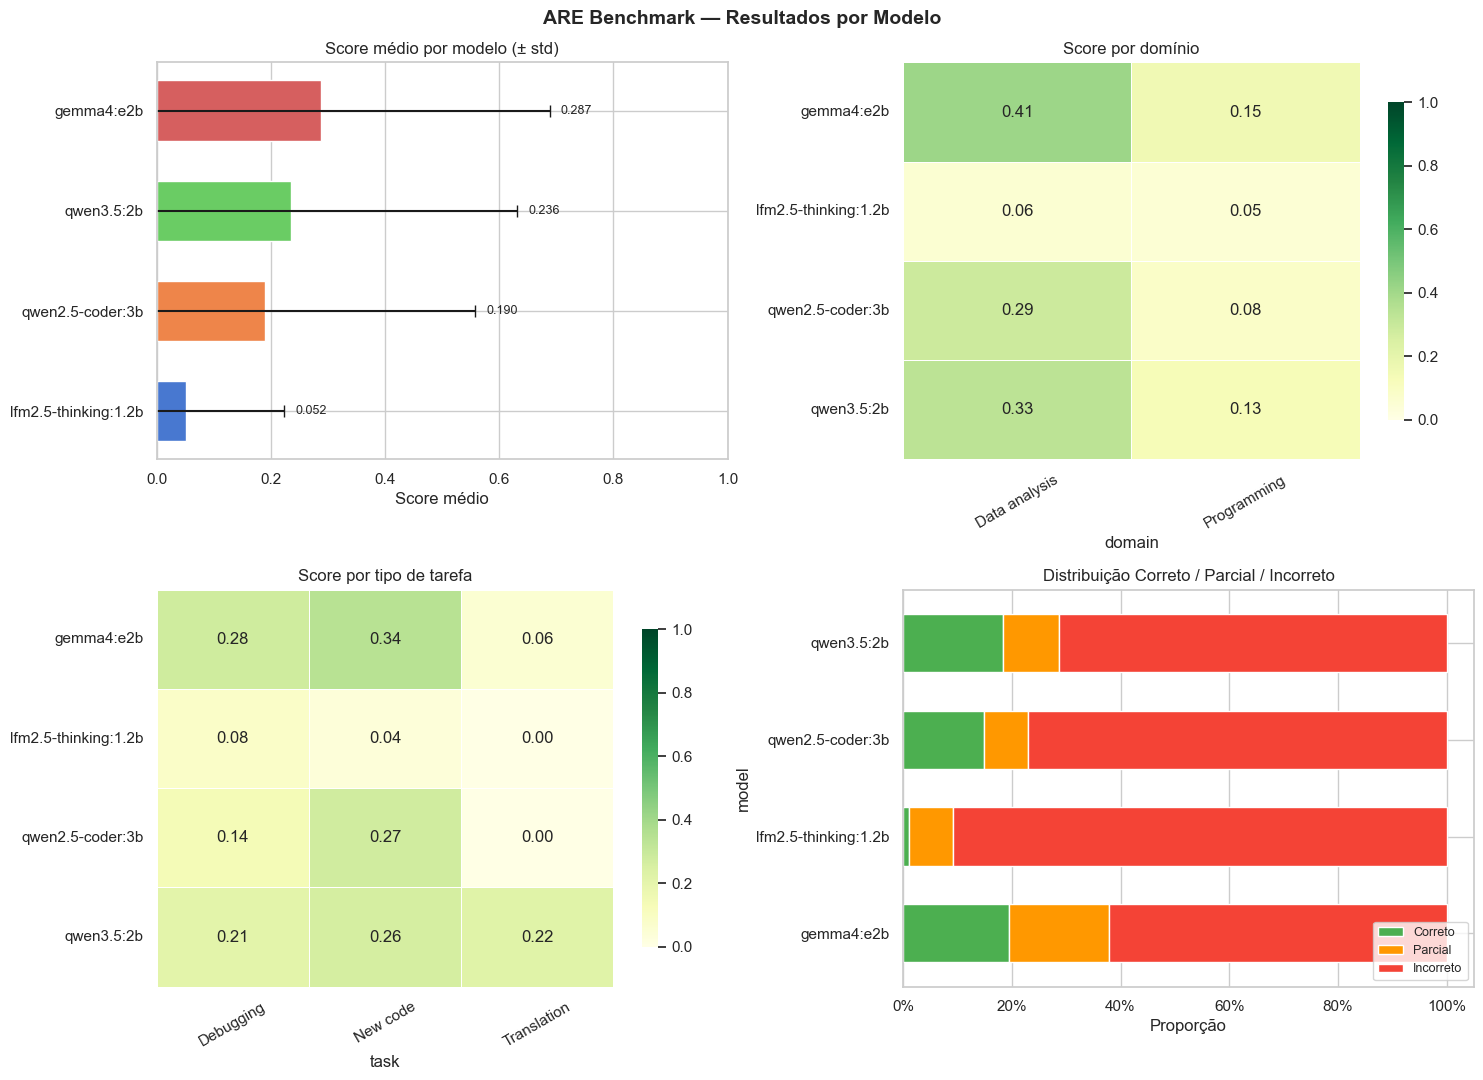

Gráfico salvo em results\benchmark_results.png


In [10]:
if not all_records:
    print("Nenhum resultado encontrado em results/. Execute o benchmark primeiro.")
else:
    fig, axes = plt.subplots(2, 2, figsize=(15, 11))
    fig.suptitle("ARE Benchmark — Resultados por Modelo", fontsize=14, fontweight="bold")

    # 1. Score médio por modelo (barras horizontais com desvio padrão)
    ax1 = axes[0, 0]
    s = summary.sort_values("mean")
    colors = sns.color_palette("muted", len(s))
    ax1.barh(s.index, s["mean"], xerr=s["std"], color=colors, capsize=4, height=0.6)
    ax1.set_xlabel("Score médio")
    ax1.set_title("Score médio por modelo (± std)")
    ax1.set_xlim(0, 1)
    for i, (val, err) in enumerate(zip(s["mean"], s["std"])):
        ax1.text(min(val + err + 0.02, 0.97), i, f"{val:.3f}", va="center", fontsize=9)

    # 2. Heatmap modelo × domínio
    ax2 = axes[0, 1]
    sns.heatmap(
        domain_summary, annot=True, fmt=".2f", cmap="YlGn",
        vmin=0, vmax=1, linewidths=0.5, ax=ax2, cbar_kws={"shrink": 0.8}
    )
    ax2.set_title("Score por domínio")
    ax2.set_ylabel("")
    ax2.tick_params(axis="x", rotation=30)

    # 3. Heatmap modelo × tipo de tarefa
    ax3 = axes[1, 0]
    sns.heatmap(
        task_summary, annot=True, fmt=".2f", cmap="YlGn",
        vmin=0, vmax=1, linewidths=0.5, ax=ax3, cbar_kws={"shrink": 0.8}
    )
    ax3.set_title("Score por tipo de tarefa")
    ax3.set_ylabel("")
    ax3.tick_params(axis="x", rotation=30)

    # 4. Proporção C / P / I por modelo (stacked bar)
    ax4 = axes[1, 1]
    grade_map = {1.0: "Correto", 0.5: "Parcial", 0.0: "Incorreto"}
    results_df["grade"] = results_df["score"].map(grade_map)
    grade_pct = (
        results_df.groupby(["model", "grade"])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=["Correto", "Parcial", "Incorreto"])
        .apply(lambda x: x / x.sum(), axis=1)
    )
    grade_pct.plot(
        kind="barh", stacked=True, ax=ax4,
        color=["#4caf50", "#ff9800", "#f44336"], width=0.6
    )
    ax4.set_xlabel("Proporção")
    ax4.set_title("Distribuição Correto / Parcial / Incorreto")
    ax4.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax4.legend(loc="lower right", fontsize=9)

    plt.tight_layout()
    out_path = RESULTS_DIR / "benchmark_results.png"
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Gráfico salvo em {out_path}")

### Desempenho vs Tamanho do Modelo

Parâmetros extraídos da tag do modelo (ex: `qwen2.5-coder:3b` → 3 B).  
Tamanho em GB consultado diretamente no servidor Ollama via `client.list()`.

,model,params_b,size_gb,mean_score
0,gemma4:e2b,2.0,7.16,0.287
1,lfm2.5-thinking:1.2b,1.2,0.73,0.052
2,qwen2.5-coder:3b,3.0,1.93,0.190
3,qwen3.5:2b,2.0,2.74,0.236


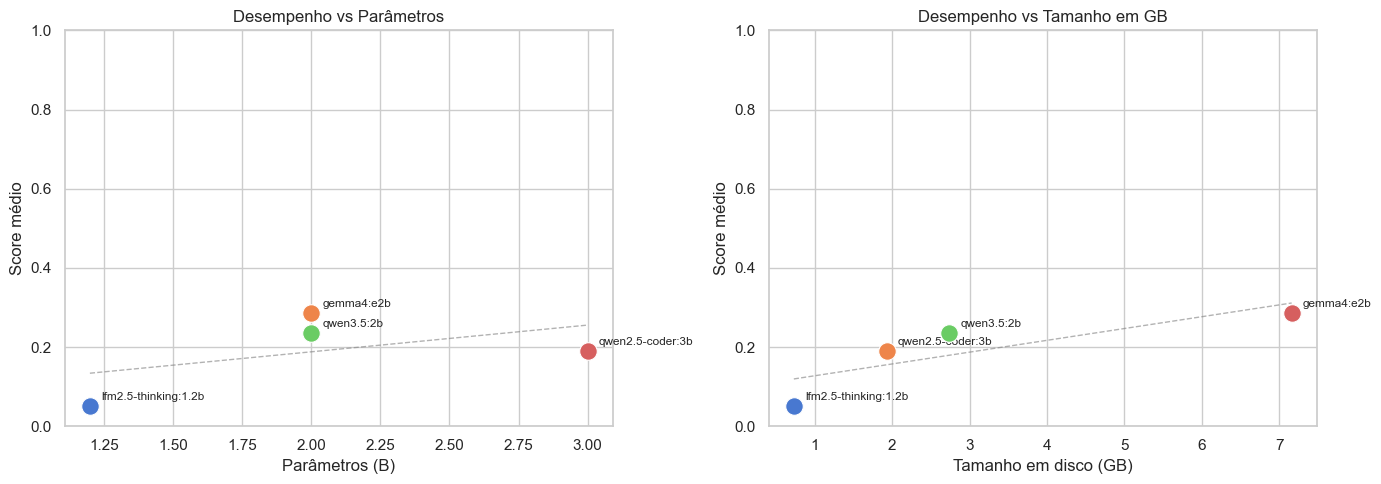

Gráfico salvo em results\benchmark_size_vs_score.png


In [11]:
def extract_params_b(model: str) -> float | None:
    tag = model.split(":")[-1] if ":" in model else model
    m = re.search(r"(\d+\.?\d*)b", tag.lower())
    return float(m.group(1)) if m else None

# Tenta buscar tamanho em disco de cada modelo no servidor
try:
    installed = {m["model"]: m for m in client.list()["models"]}
except Exception:
    installed = {}

if not all_records:
    print("Nenhum resultado encontrado. Execute o benchmark primeiro.")
else:
    model_list = results_df["model"].unique()
    size_rows = []
    for model in model_list:
        mean_score = results_df[results_df["model"] == model]["score"].mean()
        size_rows.append({
            "model":      model,
            "label":      model.split("/")[-1],
            "params_b":   extract_params_b(model),
            "size_gb":    round(installed[model]["size"] / 1e9, 2) if model in installed else None,
            "mean_score": round(mean_score, 3),
        })

    size_df = pd.DataFrame(size_rows)
    display(size_df[["model", "params_b", "size_gb", "mean_score"]])

    has_params = size_df["params_b"].notna().any()
    has_gb     = size_df["size_gb"].notna().any()
    ncols      = int(has_params) + int(has_gb)

    if ncols == 0:
        print("Sem dados de tamanho disponíveis (modelos não encontrados no servidor).")
    else:
        fig, axes = plt.subplots(1, ncols, figsize=(7 * ncols, 5))
        if ncols == 1:
            axes = [axes]
        ax_idx = 0

        def scatter_size(ax, x_col, xlabel, title):
            df = size_df.dropna(subset=[x_col]).sort_values(x_col)
            colors = sns.color_palette("muted", len(df))
            for i, (_, row) in enumerate(df.iterrows()):
                ax.scatter(row[x_col], row["mean_score"], s=160, color=colors[i],
                           zorder=5, edgecolors="white", linewidths=0.8)
                ax.annotate(
                    row["label"], (row[x_col], row["mean_score"]),
                    textcoords="offset points", xytext=(8, 4), fontsize=8.5
                )
            if len(df) >= 2:
                z = np.polyfit(df[x_col], df["mean_score"], 1)
                xs = np.linspace(df[x_col].min(), df[x_col].max(), 100)
                ax.plot(xs, np.poly1d(z)(xs), "--", color="gray", linewidth=1, alpha=0.6)
            ax.set_xlabel(xlabel)
            ax.set_ylabel("Score médio")
            ax.set_title(title)
            ax.set_ylim(0, 1)

        if has_params:
            scatter_size(axes[ax_idx], "params_b", "Parâmetros (B)",
                         "Desempenho vs Parâmetros")
            ax_idx += 1

        if has_gb:
            scatter_size(axes[ax_idx], "size_gb", "Tamanho em disco (GB)",
                         "Desempenho vs Tamanho em GB")

        plt.tight_layout()
        out_path = RESULTS_DIR / "benchmark_size_vs_score.png"
        plt.savefig(out_path, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"Gráfico salvo em {out_path}")